In [2]:
import pickle
import torch
import os
from pathlib import Path
from loguru import logger

In [3]:
expirimental_repo = {}

root = Path('../output/explanations') 
for model in os.listdir(root):
    model_path = root / model
    for dataset in os.listdir(model_path):
        dataset_path = model_path / dataset
        for explanation_file in os.listdir(dataset_path):
            explanation_path = dataset_path / explanation_file

            logger.info(f'collecting {explanation_path}')
            with open(explanation_path, 'rb') as f:
                explanation = pickle.load(f)
            
            stem = explanation_file.split('.')[0]
            split_obj = stem.split('_')
            time_seconds, time_date, explainer_class_name = split_obj[-3:]
            name = split_obj[:-3]

            expirimental_repo[(model, dataset, '_'.join(name), explainer_class_name, time_date, time_seconds)] = explanation


2026-07-23 07:28:49.760 | INFO     | __main__:<module>:11 - collecting ../output/explanations/GCN/benzene_graphs/auto_regessive_seed_ensembling_PGExplainer_20260722_185634.pkl
/workspace/xai-gnn-hdr2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-23 07:29:10.117 | INFO     | __main__:<module>:11 - collecting ../output/explanations/GCN/benzene_graphs/auto_regessive_seed_ensembling_PGExplainer_20260722_184859.pkl
2026-07-23 07:29:10.585 | INFO     | __main__:<module>:11 - collecting ../output/explanations/GCN/benzene_graphs/auto_regessive_seed_ensembling_PGExplainer_20260722_184123.pkl
2026-07-23 07:29:10.910 | INFO     | __main__:<module>:11 - collecting ../output/explanations/GCN/benzene_graphs/auto_regessive_seed_ensembling_PGExplainer_20260722_183351.pkl
2026-07-23 07:29:11.240 | INFO  

In [5]:
from pprint import pprint

for k in expirimental_repo.keys():
    pprint(k)

('GCN',
 'benzene_graphs',
 'auto_regessive_seed_ensembling',
 '185634',
 '20260722',
 'PGExplainer')
('GCN',
 'benzene_graphs',
 'auto_regessive_seed_ensembling',
 '184859',
 '20260722',
 'PGExplainer')
('GCN',
 'benzene_graphs',
 'auto_regessive_seed_ensembling',
 '184123',
 '20260722',
 'PGExplainer')
('GCN',
 'benzene_graphs',
 'auto_regessive_seed_ensembling',
 '183351',
 '20260722',
 'PGExplainer')
('GCN',
 'benzene_graphs',
 'auto_regessive_seed_ensembling',
 '182619',
 '20260722',
 'PGExplainer')
('GCN',
 'benzene_graphs',
 'seed_ensembling',
 '181852',
 '20260722',
 'PGExplainer')
('GCN',
 'benzene_graphs',
 'seed_ensembling',
 '181318',
 '20260722',
 'PGExplainer')
('GCN',
 'benzene_graphs',
 'seed_ensembling',
 '180740',
 '20260722',
 'PGExplainer')
('GCN',
 'benzene_graphs',
 'seed_ensembling',
 '180202',
 '20260722',
 'PGExplainer')
('GCN',
 'benzene_graphs',
 'seed_ensembling',
 '175627',
 '20260722',
 'PGExplainer')
('GCN', 'benzene_graphs', 'proxy_graphs', '175051', '20

In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def get_auc(edge_masks, graphs):

    edge_masks = [em.reshape(-1) for em in edge_masks]
    test_graphs = [g for g in graphs if g.test_mask == 1]
    GT_masks = [g.edge_mask for g in test_graphs]

    # ROC-AUC and ROC-PR from flat masks
    flat_edge_mask = torch.cat(edge_masks).cpu().detach().numpy()
    flat_GT_mask = torch.cat(GT_masks).cpu().detach().numpy()

    roc_auc = roc_auc_score(flat_GT_mask, flat_edge_mask)
    precision, recall, _ = precision_recall_curve(flat_GT_mask, flat_edge_mask)
    pr_auc = auc(recall, precision)

    return roc_auc, pr_auc



==== seed_ensembling ====


TypeError: Axes.bar() missing 1 required positional argument: 'x'

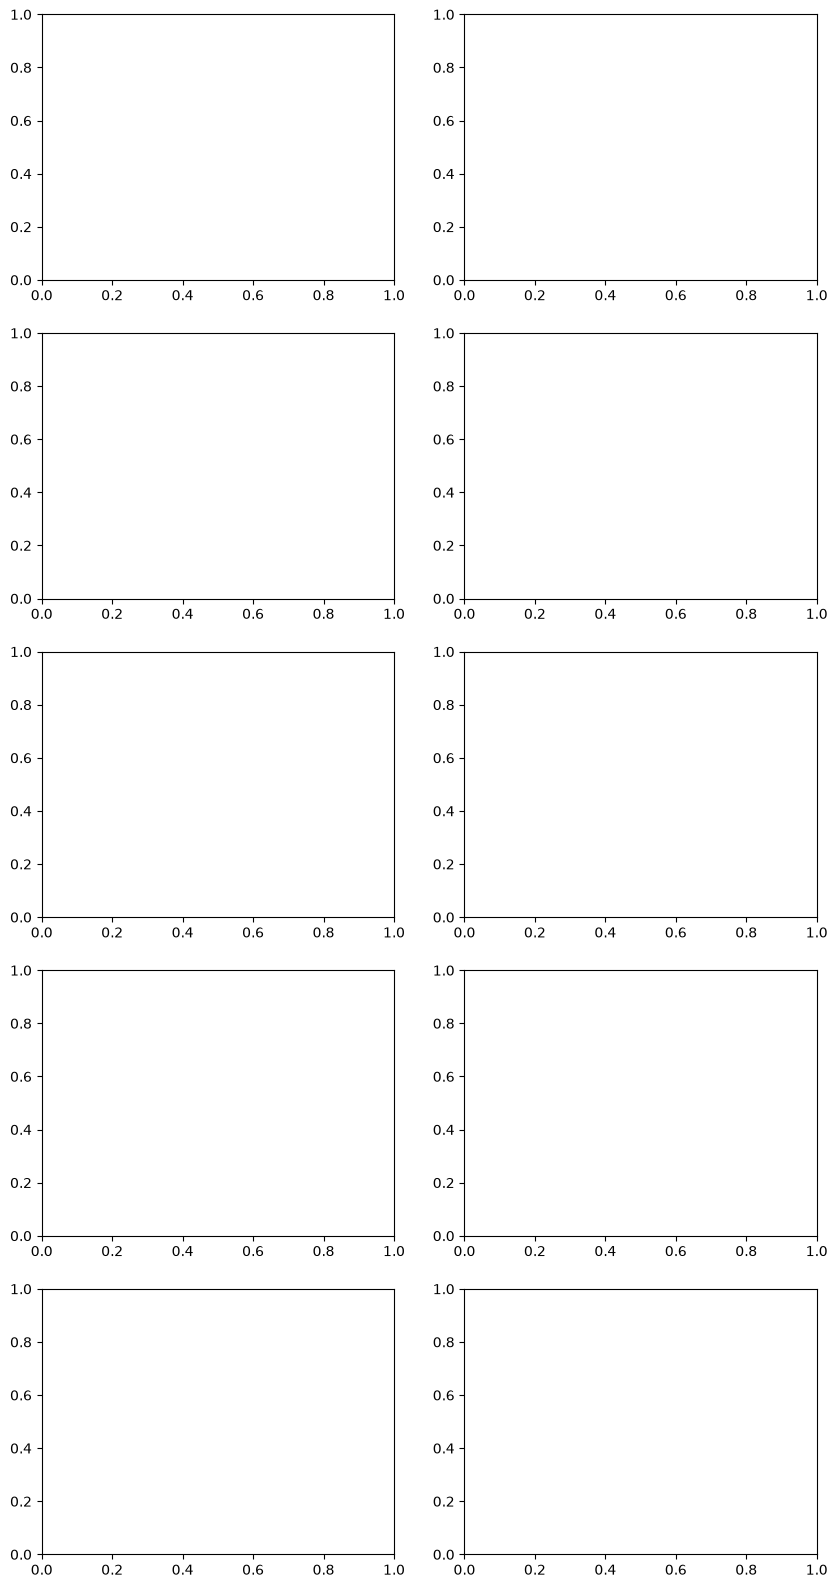

In [21]:
print('==== seed_ensembling ====')

from matplotlib import pyplot as plt


def auc_by_experimental_name(name: str = 'seed_ensembling', quiet=True):
    fig, axes = plt.subplots(5, 2, figsize=(10, 20))
    model_key = ['GIN', 'GCN']
    dataset_key = ['fluoride_carbonyl_graphs', 'ba2_graphs', 'tc_graphs', 'benzene_graphs', 'mutag']

    seed_explanations = [
        (key, explanation) for (key, explanation) in expirimental_repo.items() if key[2] == name
    ]

    for (key, explanation) in seed_explanations:
        model, dataset, name, explainer_class_name, time_date, time_seconds = key
        if not quiet:
            logger.info(f'processing {key}')

        run = explanation.run
        with open(run.dataset_root, 'rb') as f:
            graphs = pickle.load(f)

        roc_auc, pr_auc = get_auc(explanation.edge_masks, graphs)
        axes[dataset_key.index(dataset), model_key.index(model)].bar(height=roc_auc, label=f'{explainer_class_name} {time_date} {time_seconds}', alpha=0.5)
        axes[dataset_key.index(dataset), model_key.index(model)].legend()
        axes.title(f'{model}, {dataset}')

        if not quiet:
            logger.info(f'ROC-AUC: {roc_auc:.4f}, PR-AUC: {pr_auc:.4f}')



auc_by_experimental_name()
plt.show()

